In [1]:
!pip install "altair<6"


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


The Economy of Prestige for Film Soundtracks: Popularity vs\. Awards \(2015 to 2025\)

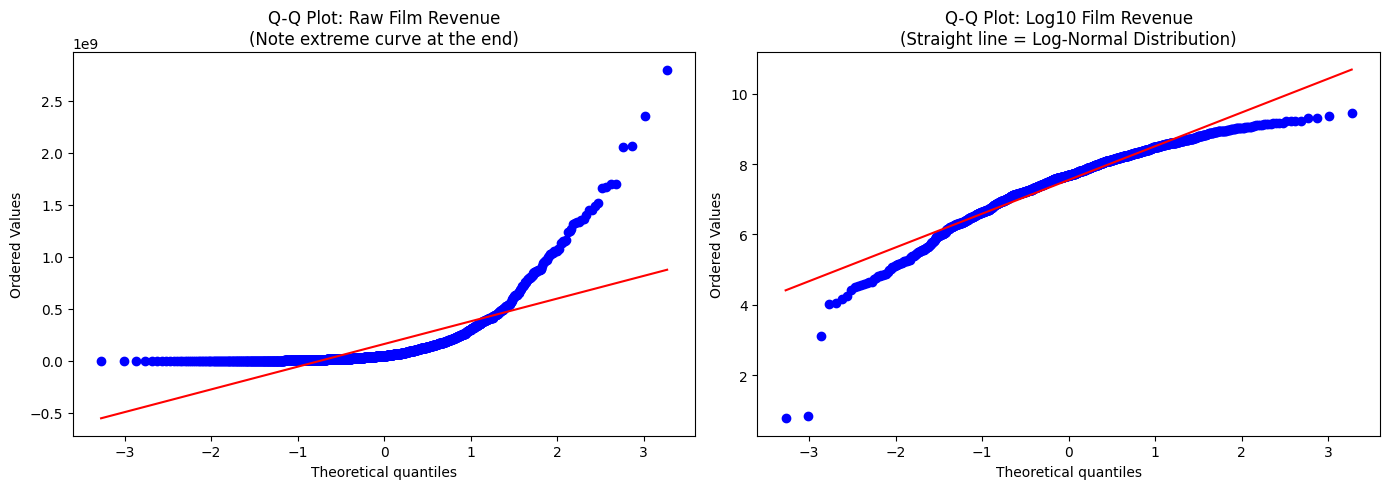

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Load your data
df = pd.read_csv('/work/pipeline/4.7.Albums_analytics_set.csv')

# 2. Filter for positive values (Log cannot handle 0 or negative numbers)
# This matches the logic used for your scatter plot
filtered_df = df[(df['film_revenue'] > 0) & (df['lfm_album_playcount'] > 0)].copy()

# 3. Setup a 1x2 grid for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- REVENUE ANALYSIS ---
# Raw Revenue: Use axes[0] instead of axes[0, 0]
stats.probplot(filtered_df['film_revenue'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Raw Film Revenue\n(Note extreme curve at the end)')

# Log Revenue: Use axes[1] instead of axes[0, 1]
stats.probplot(np.log10(filtered_df['film_revenue']), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Log10 Film Revenue\n(Straight line = Log-Normal Distribution)')

plt.tight_layout()
plt.show()

What these plots tell us:
The Red Line: This represents a perfect "Normal Distribution\."

The Blue Dots: The  actual data points\.

The Interpretation:

If the dots follow the red line \(Log Plots\): This is the "smoking gun" proof that a Log Scale is the mathematically correct way to visualize this data\. It confirms that "success" in your dataset happens on an exponential scale rather than a linear one\.

Why this matters for your Quadrant Chart:
If the Log10 plots are straighter than the Raw plots, it proves that our medians are meaningful\. In a skewed raw distribution, the median is often buried near the bottom; in a log\-normal distribution, the median sits in the "center" of the growth curve, making your quadrants \(High vs\. Low\) much more accurate\.

The analysis of soundtrack streaming performance between 2015 and 2025 leads to several key conclusions regarding what drives listenership in the modern digital era\. 

In [3]:
# Third-party imports
import altair as alt
import pandas as pd

# 1. Load data
df = pd.read_csv('/work/pipeline/4.7.Albums_analytics_set.csv')

# 2. Define award categories (keeping your logic)
award_definitions = {
    'Oscars': {
        'nominees': ['oscar_score_nominee', 'oscar_score_winner', 'oscar_song_nominee', 'oscar_song_winner'],
        'winners': ['oscar_score_winner', 'oscar_song_winner']
    },
    'Golden Globes': {
        'nominees': ['globes_score_nominee', 'globes_score_winner', 'globes_song_nominee', 'globes_song_winner'],
        'winners': ['globes_score_winner', 'globes_song_winner']
    },
    'Critics Choice': {
        'nominees': ['critics_score_nominee', 'critics_score_winner', 'critics_song_nominee', 'critics_song_winner'],
        'winners': ['critics_score_winner', 'critics_song_winner']
    },
    'BAFTA': {
        'nominees': ['bafta_score_nominee', 'bafta_score_winner'],
        'winners': ['bafta_score_winner']
    }
}

# 3. Process status
status_cols = []
for award, cols in award_definitions.items():
    status_col = f'{award}_Status'
    status_cols.append(status_col)
    any_nominee = df[cols['nominees']].fillna(False).any(axis=1)
    any_winner = df[cols['winners']].fillna(False).any(axis=1)
    df[status_col] = 'Not Nominated'
    df.loc[any_nominee, status_col] = 'Nominated'
    df.loc[any_winner, status_col] = 'Winner'

# 4. Filter for valid data
# We specifically ensure revenue is at least 10k to match our visual truncation
financial_df = df[(df['film_budget'] > 0) & 
                  (df['film_revenue'] >= 10000) & 
                  (df['lfm_album_playcount'] > 0)].copy()

# 5. Transform to Long Format
long_df = financial_df.melt(
    id_vars=['film_title', 'film_revenue', 'film_popularity', 'lfm_album_playcount'],
    value_vars=status_cols,
    var_name='Award_Type',
    value_name='Award_Status'
)
long_df['Award_Type'] = long_df['Award_Type'].str.replace('_Status', '')

status_order = ['Not Nominated', 'Nominated', 'Winner']
long_df['Award_Status'] = pd.Categorical(long_df['Award_Status'], categories=status_order, ordered=True)
long_df = long_df.sort_values('Award_Status')

# ---------------------------------------------------------
# CALCULATION: Medians (Based on the filtered 10k+ dataset)
# ---------------------------------------------------------
med_pop = long_df['film_popularity'].median()
med_rev = long_df['film_revenue'].median()

# ---------------------------------------------------------
# CHART DEFINITION
# ---------------------------------------------------------

# Median Lines
rule_x = alt.Chart(pd.DataFrame({'x': [med_pop]})).mark_rule(
    strokeDash=[4,4], color='#555555', opacity=0.7, strokeWidth=1.5
).encode(x='x:Q')

rule_y = alt.Chart(pd.DataFrame({'y': [med_rev]})).mark_rule(
    strokeDash=[4,4], color='#555555', opacity=0.7, strokeWidth=1.5
).encode(y='y:Q')

# Points
points = alt.Chart().mark_circle(stroke='white', strokeWidth=0.5).encode(
    x=alt.X('film_popularity:Q', 
            title='Film Popularity (Log Scale)', 
            scale=alt.Scale(type='log'), 
            axis=alt.Axis(grid=False, ticks=False, labels=False, domain=False)), 
    
    y=alt.Y('film_revenue:Q', 
            title='Revenue ($) (Log Scale)', 
            # TRUNCATION: Set the domain to start at 10,000
            scale=alt.Scale(type='log', domain=[10000, long_df['film_revenue'].max()], clamp=True), 
            axis=alt.Axis(grid=False, ticks=False, domain=False)),
            
    size=alt.Size('lfm_album_playcount:Q', scale=alt.Scale(range=[10,1500])),
    color=alt.Color('Award_Status:N', scale=alt.Scale(domain=['Winner', 'Nominated', 'Not Nominated'], range=['#7922cc', '#ce0000', '#BDC3C7'])),
    opacity=alt.Opacity('Award_Status:N', scale=alt.Scale(range=[0.8, 0.5, 0.15]), legend=None),
    tooltip=[
        alt.Tooltip('film_title:N', title='Movie'),
        alt.Tooltip('Award_Status:N', title='Status'), # Added this for you
        alt.Tooltip('film_revenue:Q', title='Revenue', format='$,.0f'),
        alt.Tooltip('lfm_album_playcount:Q', title='Album Plays', format=','),
        alt.Tooltip('film_popularity:Q', title='Popularity Score', format='.1f')
    ]
)

layered_chart = alt.layer(
    rule_x, rule_y, points,
    data=long_df
).properties(
    width=320,
    height=250
)

revenue_chart = layered_chart.facet(
    facet='Award_Type:N', 
    columns=2, 
    title='Revenue vs Film & Album Engagement (2015 to 2025)'
).configure_view(
    stroke=None
).resolve_scale(
    x='shared', 
    y='shared'
).interactive()

revenue_chart.display()

alt.FacetChart(...)

The chart is a multi faceted one representing the relationship of revenue, film popularity, soundtrack popularity and award status\. It is interactive and lets you hover over \(see tooltips\) and look at specific data points and details\. We the four quadrants based on the observation in our previous qq plots based on medians\. We see some interesting things in the charts, almost all the wins are in the upper right quadrant indicating the awards bodies are skewed towards high revenue and higher popularity movies\. 

Expressiveness: 

Log Scale Integrity: By using the log scale for both revenue and film popularity we are accurately expressing the relative change rather than absolute differences\. In film data, blockbusters earn 1000x more than say an idie movie so a linear scale would crush all but three points into a corner\. This choice of using a log scale is expressive of the industry\.  

The use of a claim=True and a 10K floor for revenue is a necessary lie for the sake of clarity\. By filtering and clamping, we express the data that matters without breaking geometry of our plot\. 

By splitting the awards into four facets, we express the unique vibe of each ceremony or award type\. For example, the BAFTA shows a smaller more concentrated cluster of winners compared to the Golden Globes expressing the exclusivity of different voting bodies\. 

We also don't hide the non nominated movies and express them as grey dots\. 

Effectiveness:

The chart uses high precision encoding to guide the viewer through data from various different sources\. 

The Four Quadrant story \(Medians\) are effective analytical tool here\. 

Color was used as an identity to effectively tell whether a data point is an awardee, nominee or none when it comes to its award status with the four bodies\. 

Size of the bubble was used to indicate a 3rd quantitative dimension i\.e\. the popularity of the soundtrack\. 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b124131d-2024-4253-bb46-8043aed4b78f' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>